In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Load Cleaned Data

In [2]:
df = pd.read_csv("retail_forecasting_cleaned_v2.csv")
df["date"] = pd.to_datetime(df["date"])

print("Daily data loaded:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("SKUs:", df["sku_id"].nunique())

Daily data loaded: (365000, 22)
Date range: 2021-08-14 → 2026-08-12
SKUs: 200


# # 1. Aggregate to WEEKLY (SKU × week)

In [3]:
df["year_week"] = df["date"].dt.to_period("W-SUN")

weekly = (
    df.groupby(["sku_id", "year_week"], as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        avg_price=("unit_price", "mean"),
        on_hand=("on_hand_units", "last"),
        on_order=("on_order_units", "last"),
        lead_time=("lead_time_days", "mean"),
        reorder_point=("reorder_point", "mean"),
        promo_days=("promo_flag", "sum"),
        holiday_days=("is_holiday", "sum"),
        category=("category", "first"),
        subcategory=("subcategory", "first"),
        region=("region", "first")
    )
)

weekly["week_start"] = weekly["year_week"].dt.start_time
weekly = weekly.sort_values(["sku_id", "week_start"]).reset_index(drop=True)

print("\nWeekly shape:", weekly.shape)
print("Week range:", weekly["week_start"].min().date(), "→", weekly["week_start"].max().date())
print("Columns:", weekly.columns.tolist())


Weekly shape: (52400, 15)
Week range: 2021-08-09 → 2026-08-10
Columns: ['sku_id', 'year_week', 'units_sold', 'revenue', 'avg_price', 'on_hand', 'on_order', 'lead_time', 'reorder_point', 'promo_days', 'holiday_days', 'category', 'subcategory', 'region', 'week_start']


## 2. Feature Engineering

In [4]:
def add_features(group):
    group = group.sort_values("week_start").copy()

    # Lag features
    group["lag_1"]  = group["units_sold"].shift(1)
    group["lag_2"]  = group["units_sold"].shift(2)
    group["lag_4"]  = group["units_sold"].shift(4)
    group["lag_52"] = group["units_sold"].shift(52)

    # Rolling features (using only past data)
    group["roll_mean_4"] = group["units_sold"].shift(1).rolling(4, min_periods=1).mean()
    group["roll_mean_8"] = group["units_sold"].shift(1).rolling(8, min_periods=1).mean()
    group["roll_std_4"]  = group["units_sold"].shift(1).rolling(4, min_periods=1).std()

    # Calendar features
    group["weekofyear"] = group["week_start"].dt.isocalendar().week.astype(int)
    group["month"] = group["week_start"].dt.month
    group["quarter"] = group["week_start"].dt.quarter

    return group

weekly = weekly.groupby("sku_id", group_keys=False).apply(add_features)
weekly = weekly.reset_index(drop=True)

print("\nFeatures created successfully.")
print("Sample:")
print(weekly[["sku_id", "week_start", "units_sold", "lag_1", "lag_52", "roll_mean_4"]].head(8))


Features created successfully.
Sample:
    sku_id week_start  units_sold  lag_1  lag_52  roll_mean_4
0  SKU0001 2021-08-09           0    NaN     NaN          NaN
1  SKU0001 2021-08-16           0    0.0     NaN          0.0
2  SKU0001 2021-08-23           0    0.0     NaN          0.0
3  SKU0001 2021-08-30           0    0.0     NaN          0.0
4  SKU0001 2021-09-06           0    0.0     NaN          0.0
5  SKU0001 2021-09-13           0    0.0     NaN          0.0
6  SKU0001 2021-09-20           0    0.0     NaN          0.0
7  SKU0001 2021-09-27           0    0.0     NaN          0.0


In [5]:
# # 3. Seasonal-Naive Baseline

In [6]:
# Forecast = same week last year (lag_52)
# Fallback: lag_4 → lag_1 → 0

weekly["baseline_pred"] = weekly["lag_52"]
weekly["baseline_pred"] = weekly["baseline_pred"].fillna(weekly["lag_4"])
weekly["baseline_pred"] = weekly["baseline_pred"].fillna(weekly["lag_1"])
weekly["baseline_pred"] = weekly["baseline_pred"].fillna(0)

print("\nBaseline predictions created.")


Baseline predictions created.


 # 4. Evaluation — WAPE

In [7]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denominator * 100

# Overall
overall_wape = wape(weekly["units_sold"], weekly["baseline_pred"])

# Last 52 weeks
cutoff = weekly["week_start"].max() - pd.Timedelta(weeks=52)
recent = weekly[weekly["week_start"] >= cutoff]
recent_wape = wape(recent["units_sold"], recent["baseline_pred"])

print("\n" + "="*45)
print("SEASONAL-NAIVE BASELINE RESULTS")
print("="*45)
print(f"Overall WAPE       : {overall_wape:.2f}%")
print(f"Last 1 year WAPE   : {recent_wape:.2f}%")
print("\nWAPE by category:")
for cat in sorted(weekly["category"].unique()):
    mask = weekly["category"] == cat
    score = wape(weekly.loc[mask, "units_sold"], weekly.loc[mask, "baseline_pred"])
    print(f"  {cat:<20}: {score:.2f}%")


SEASONAL-NAIVE BASELINE RESULTS
Overall WAPE       : 32.12%
Last 1 year WAPE   : 31.26%

WAPE by category:
  Decor               : 30.02%
  Furniture           : 31.72%
  Small Appliances    : 36.84%


# 5. Visual check (one SKU)

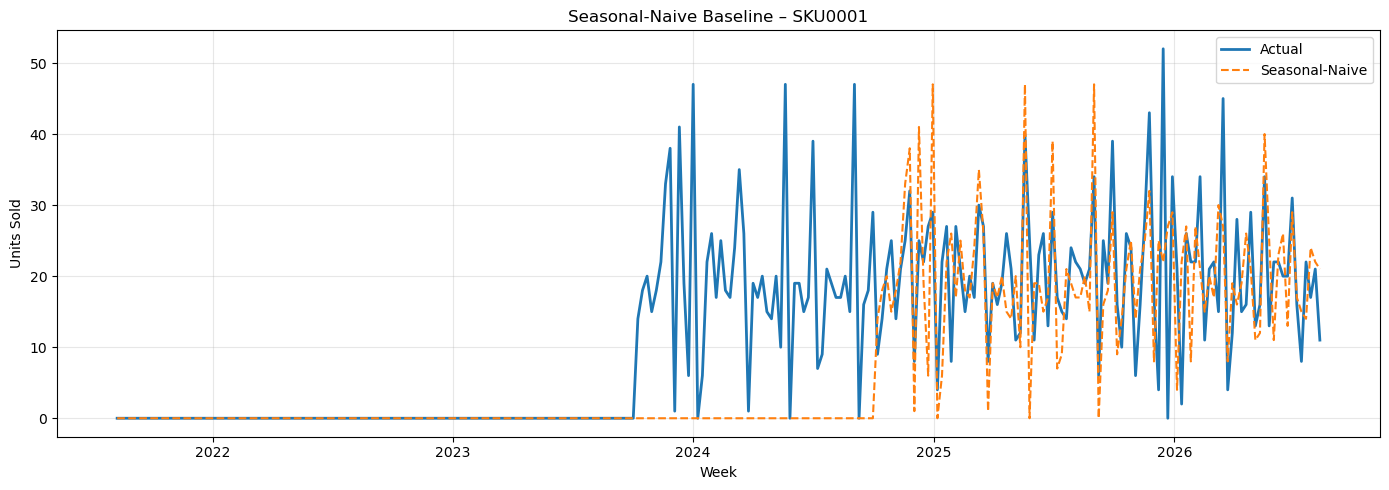

In [8]:
sku = "SKU0001"
sample = weekly[weekly["sku_id"] == sku].copy()

plt.figure(figsize=(14, 5))
plt.plot(sample["week_start"], sample["units_sold"], label="Actual", linewidth=2)
plt.plot(sample["week_start"], sample["baseline_pred"], label="Seasonal-Naive", linestyle="--")
plt.title(f"Seasonal-Naive Baseline – {sku}")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# # 6. Save the modelling dataset

In [9]:
weekly.to_csv("weekly_forecast_ready.csv", index=False)
print("\nSaved: weekly_forecast_ready.csv")
print("Final shape:", weekly.shape)
print("Done — Stages 4, 5 & 6 complete.")


Saved: weekly_forecast_ready.csv
Final shape: (52400, 26)
Done — Stages 4, 5 & 6 complete.
